# EDA dos conjuntos rotulados enriquecidos com assunto

Este notebook explora os arquivos:

- `data/annotations_corrected_2001_with_assunto.json`
- `data/dd_corpus_small_test_with_assunto.json`

O foco principal é comparar as distribuições de `assunto` entre treino e teste, considerando apenas os relatos para os quais o assunto foi recuperado sem ambiguidade.

In [1]:
from pathlib import Path
import json
import math
import os
import re
from collections import Counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import pandas as pd

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None
    plt.style.use("ggplot")

TRAIN_PATH = Path("../data/annotations_corrected_2001_with_assunto.json")
TEST_PATH = Path("../data/dd_corpus_small_test_with_assunto.json")
OUT_DIR = Path("../artifacts/eda/enriched_train_test")

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 120)

## Carregamento

In [2]:
def load_json_array(path: Path) -> list[dict]:
    data = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(data, list):
        raise ValueError(f"Expected JSON array: {path}")
    return data

def rows_to_frame(rows: list[dict], split: str) -> pd.DataFrame:
    records = []
    for idx, row in enumerate(rows):
        spans = row.get("spans") if isinstance(row.get("spans"), list) else []
        match = row.get("_source_assunto_match") if isinstance(row.get("_source_assunto_match"), dict) else {}
        label_counts = Counter(str(span.get("label")) for span in spans if isinstance(span, dict) and span.get("label"))
        text = row.get("text", "") if isinstance(row.get("text"), str) else ""
        records.append({
            "split": split,
            "row_index": idx,
            "text": text,
            "assunto": row.get("assunto", ""),
            "has_assunto": bool(row.get("assunto")),
            "match_status": match.get("status", ""),
            "match_strategy": match.get("strategy", ""),
            "source_partitions": "|".join(match.get("source_partitions", [])) if isinstance(match.get("source_partitions"), list) else "",
            "text_chars": len(text),
            "text_words": len(re.findall(r"\b\w+\b", text, flags=re.UNICODE)),
            "span_count": len(spans),
            "location_count": label_counts.get("Location", 0),
            "person_count": label_counts.get("Person", 0),
            "organization_count": label_counts.get("Organization", 0),
        })
    return pd.DataFrame(records)

train_rows = load_json_array(TRAIN_PATH)
test_rows = load_json_array(TEST_PATH)
df = pd.concat([
    rows_to_frame(train_rows, "train"),
    rows_to_frame(test_rows, "test"),
], ignore_index=True)

print(f"train rows: {len(train_rows):,}")
print(f"test rows: {len(test_rows):,}")
df.head()

train rows: 4,226
test rows: 792


,split,row_index,text,assunto,has_assunto,match_status,match_strategy,source_partitions,text_chars,text_words,span_count,location_count,person_count,organization_count
0,train,0,"Casa onde fica guardada drogas dá facção comando vermelho , cocaína e maconha do Fernando beira mar , sob comando dos filhos de beira mar , armas , dinheoro , drogas , meliante...",,False,unmatched,,,255,42,4,0,3,1
1,train,1,De 4 a 8 homens armados montaram uma boca de fumo nessa rua . Eles se escondem e invadem a casa de moradores todos os dias . Fizeram barricadas nas duas esquinas da rua utiliza...,,False,unmatched,,,394,68,1,0,1,0
2,train,2,Uso e tráfico de drogas na rua Germano Faber . Usuários e traficantes durante o dia e a noite usando drogas sem se importar com as pessoas passando . A rua tem crianças passean...,,False,unmatched,,,359,58,1,1,0,0
3,train,3,"Homens armados estão traficando drogas na rua aldrovando pena no vila 3 na localidade conhecida como favelinha , a rua aldrovando no sentido favelinha é termina com um beco e o...",,False,unmatched,,,1425,254,14,14,0,0
4,train,4,Citroën c3 branco abandonado,Roubo carga/ veículo,True,matched_unique,exact,dropped,28,4,0,0,0,0


## Cobertura da recuperação de assunto

Antes de comparar distribuições, é importante separar cobertura de assunto de distribuição de assunto. A comparação principal abaixo usa apenas relatos com `assunto` recuperado.

In [3]:
coverage = (
    df.groupby("split")
    .agg(
        rows=("text", "size"),
        rows_with_assunto=("has_assunto", "sum"),
        rows_without_assunto=("has_assunto", lambda s: (~s).sum()),
    )
)
coverage["assunto_coverage"] = coverage["rows_with_assunto"] / coverage["rows"]
coverage

,rows,rows_with_assunto,rows_without_assunto,assunto_coverage
split,,,,
test,792,510,282,0.643939
train,4226,2602,1624,0.615712


In [4]:
match_status_table = pd.crosstab(df["split"], df["match_status"], margins=True)
match_status_table

match_status,matched_ambiguous_assunto,matched_duplicate_same_assunto,matched_unique,unmatched,All
split,,,,,
test,39,97,413,243,792
train,188,457,2145,1436,4226
All,227,554,2558,1679,5018


In [5]:
pd.crosstab(df["split"], df["source_partitions"], margins=True)

source_partitions,,dropped,dropped|flagged,dropped|flagged|sanitized,dropped|sanitized,flagged,sanitized,All
split,,,,,,,,
test,243,135,8,0,86,22,298,792
train,1436,612,45,1,426,147,1559,4226
All,1679,747,53,1,512,169,1857,5018


## Distribuição de assuntos

A tabela abaixo mostra contagens e proporções por split considerando apenas relatos com `assunto`.

In [6]:
df_subject = df[df["has_assunto"]].copy()

subject_counts = (
    df_subject.groupby(["split", "assunto"])
    .size()
    .rename("count")
    .reset_index()
)
subject_counts["share"] = subject_counts["count"] / subject_counts.groupby("split")["count"].transform("sum")

subject_pivot_counts = subject_counts.pivot(index="assunto", columns="split", values="count").fillna(0).astype(int)
subject_pivot_shares = subject_counts.pivot(index="assunto", columns="split", values="share").fillna(0.0)

comparison = subject_pivot_counts.join(subject_pivot_shares, lsuffix="_count", rsuffix="_share")
comparison = comparison.rename(columns={
    "train_count": "train_n",
    "test_count": "test_n",
    "train_share": "train_share",
    "test_share": "test_share",
})
comparison["share_diff_test_minus_train"] = comparison["test_share"] - comparison["train_share"]
comparison["share_ratio_test_over_train"] = comparison.apply(
    lambda row: row["test_share"] / row["train_share"] if row["train_share"] > 0 else math.inf,
    axis=1,
)
comparison.sort_values("train_n", ascending=False)

split,test_n,train_n,test_share,train_share,share_diff_test_minus_train,share_ratio_test_over_train
assunto,,,,,,
Tráfico de Drogas - Armas,262,1330,0.513725,0.511145,0.002580,1.005048
Roubo carga/ veículo,107,522,0.209804,0.200615,0.009189,1.045804
Homicídios,47,275,0.092157,0.105688,-0.013531,0.871971
Roubos em Geral,45,260,0.088235,0.099923,-0.011688,0.883032
Armas,49,215,0.096078,0.082629,0.013450,1.162772


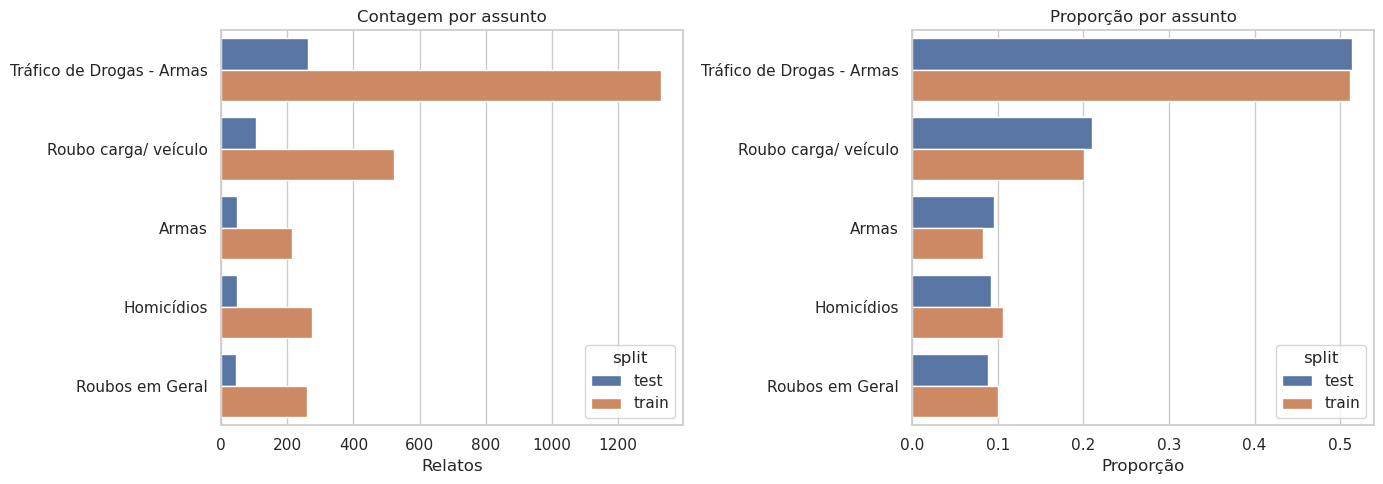

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_counts = subject_counts.sort_values(["split", "count"], ascending=[True, False])
if sns is not None:
    sns.barplot(data=plot_counts, x="count", y="assunto", hue="split", ax=axes[0])
    sns.barplot(data=plot_counts, x="share", y="assunto", hue="split", ax=axes[1])
else:
    subject_pivot_counts.plot(kind="barh", ax=axes[0])
    subject_pivot_shares.plot(kind="barh", ax=axes[1])

axes[0].set_title("Contagem por assunto")
axes[0].set_xlabel("Relatos")
axes[0].set_ylabel("")
axes[1].set_title("Proporção por assunto")
axes[1].set_xlabel("Proporção")
axes[1].set_ylabel("")
plt.tight_layout()

## As distribuições de assunto são similares?

As métricas abaixo comparam as distribuições empíricas de `assunto` entre treino e teste:

- `total_variation_distance`: 0 indica distribuições idênticas; 1 indica separação máxima.
- `jensen_shannon_divergence`: 0 indica distribuições idênticas; valores maiores indicam mais divergência.
- `chi_square_statistic`: estatística do teste qui-quadrado em tabela 2 x K.
- `cramers_v`: tamanho de efeito do qui-quadrado; 0 indica associação nula entre split e assunto.

Se `scipy` estiver instalado, o notebook também calcula `p_value`. Caso contrário, as métricas descritivas continuam disponíveis.

In [8]:
def align_distributions(counts: pd.DataFrame) -> tuple[pd.Series, pd.Series]:
    train = counts.get("train", pd.Series(dtype=float)).astype(float)
    test = counts.get("test", pd.Series(dtype=float)).astype(float)
    index = train.index.union(test.index)
    return train.reindex(index, fill_value=0.0), test.reindex(index, fill_value=0.0)

def total_variation_distance(p: pd.Series, q: pd.Series) -> float:
    return 0.5 * float((p - q).abs().sum())

def kl_divergence(p: pd.Series, q: pd.Series) -> float:
    total = 0.0
    for pi, qi in zip(p, q):
        if pi > 0 and qi > 0:
            total += float(pi * math.log(pi / qi, 2))
    return total

def jensen_shannon_divergence(p: pd.Series, q: pd.Series) -> float:
    m = 0.5 * (p + q)
    return 0.5 * kl_divergence(p, m) + 0.5 * kl_divergence(q, m)

def chi_square_2xk(counts: pd.DataFrame) -> tuple[float, int]:
    observed = counts.T.astype(float)
    row_totals = observed.sum(axis=1)
    col_totals = observed.sum(axis=0)
    grand_total = float(row_totals.sum())
    expected = pd.DataFrame(index=observed.index, columns=observed.columns, dtype=float)
    for row in observed.index:
        for col in observed.columns:
            expected.loc[row, col] = row_totals[row] * col_totals[col] / grand_total
    statistic = (((observed - expected) ** 2) / expected).to_numpy().sum()
    dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)
    return float(statistic), int(dof)

train_counts, test_counts = align_distributions(subject_pivot_counts)
train_dist = train_counts / train_counts.sum()
test_dist = test_counts / test_counts.sum()

chi2_stat, chi2_dof = chi_square_2xk(subject_pivot_counts)
n_total = int(train_counts.sum() + test_counts.sum())
cramers_v = math.sqrt(chi2_stat / n_total) if n_total else math.nan

try:
    from scipy.stats import chi2_contingency
    scipy_chi2, p_value, scipy_dof, expected = chi2_contingency(subject_pivot_counts.T)
except Exception:
    p_value = None
    scipy_chi2 = None
    scipy_dof = None

similarity_metrics = pd.DataFrame([{
    "train_rows_with_assunto": int(train_counts.sum()),
    "test_rows_with_assunto": int(test_counts.sum()),
    "total_variation_distance": total_variation_distance(train_dist, test_dist),
    "jensen_shannon_divergence_bits": jensen_shannon_divergence(train_dist, test_dist),
    "chi_square_statistic": chi2_stat,
    "chi_square_dof": chi2_dof,
    "chi_square_p_value": p_value,
    "cramers_v": cramers_v,
}])
similarity_metrics

,train_rows_with_assunto,test_rows_with_assunto,total_variation_distance,jensen_shannon_divergence_bits,chi_square_statistic,chi_square_dof,chi_square_p_value,cramers_v
0,2602,510,0.025219,0.001038,2.441872,4,0.655074,0.028012


In [9]:
dist_compare = pd.DataFrame({
    "train_share": train_dist,
    "test_share": test_dist,
})
dist_compare["abs_diff"] = (dist_compare["test_share"] - dist_compare["train_share"]).abs()
dist_compare["signed_diff_test_minus_train"] = dist_compare["test_share"] - dist_compare["train_share"]
dist_compare.sort_values("abs_diff", ascending=False)

,train_share,test_share,abs_diff,signed_diff_test_minus_train
assunto,,,,
Homicídios,0.105688,0.092157,0.013531,-0.013531
Armas,0.082629,0.096078,0.013450,0.013450
Roubos em Geral,0.099923,0.088235,0.011688,-0.011688
Roubo carga/ veículo,0.200615,0.209804,0.009189,0.009189
Tráfico de Drogas - Armas,0.511145,0.513725,0.002580,0.002580


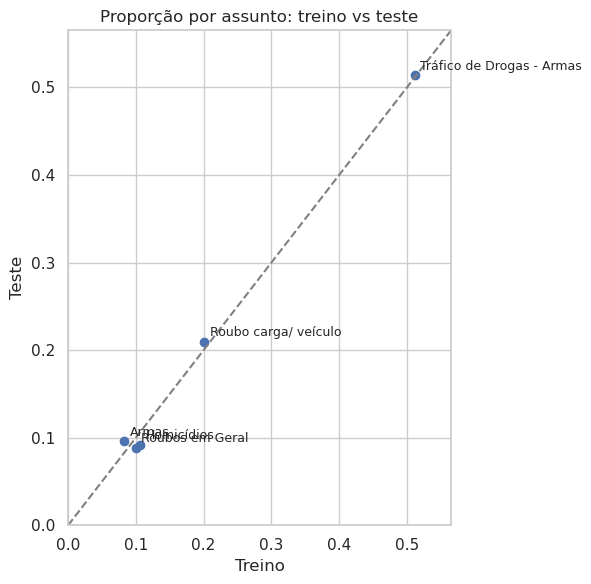

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(dist_compare["train_share"], dist_compare["test_share"])
limit = max(dist_compare["train_share"].max(), dist_compare["test_share"].max()) * 1.1
plt.plot([0, limit], [0, limit], linestyle="--", color="gray")
for assunto, row in dist_compare.iterrows():
    plt.annotate(assunto, (row["train_share"], row["test_share"]), fontsize=9, xytext=(4, 4), textcoords="offset points")
plt.title("Proporção por assunto: treino vs teste")
plt.xlabel("Treino")
plt.ylabel("Teste")
plt.xlim(0, limit)
plt.ylim(0, limit)
plt.tight_layout()

## Distribuições de entidades por assunto

Além da quantidade de relatos, é útil verificar se assuntos diferentes têm perfis distintos de entidades anotadas.

In [11]:
entity_by_subject = (
    df_subject.groupby(["split", "assunto"])
    .agg(
        rows=("text", "size"),
        avg_spans=("span_count", "mean"),
        median_spans=("span_count", "median"),
        avg_locations=("location_count", "mean"),
        avg_persons=("person_count", "mean"),
        avg_organizations=("organization_count", "mean"),
        total_locations=("location_count", "sum"),
        total_persons=("person_count", "sum"),
        total_organizations=("organization_count", "sum"),
    )
    .reset_index()
)
entity_by_subject

,split,assunto,rows,avg_spans,median_spans,avg_locations,avg_persons,avg_organizations,total_locations,total_persons,total_organizations
0,test,Armas,49,2.285714,2.0,1.306122,0.387755,0.591837,64,19,29
1,test,Homicídios,47,6.234043,4.0,2.340426,3.000000,0.893617,110,141,42
2,test,Roubo carga/ veículo,107,2.897196,2.0,1.831776,0.672897,0.392523,196,72,42
3,test,Roubos em Geral,45,2.800000,2.0,1.911111,0.288889,0.600000,86,13,27
4,test,Tráfico de Drogas - Armas,262,3.217557,2.0,1.954198,0.599237,0.664122,512,157,174
5,train,Armas,215,2.316279,2.0,1.525581,0.520930,0.269767,328,112,58
6,train,Homicídios,275,5.705455,4.0,3.007273,2.334545,0.363636,827,642,100
7,train,Roubo carga/ veículo,522,2.641762,2.0,1.942529,0.350575,0.348659,1014,183,182
8,train,Roubos em Geral,260,2.542308,2.0,1.784615,0.438462,0.319231,464,114,83
9,train,Tráfico de Drogas - Armas,1330,3.223308,2.0,2.269173,0.615038,0.339098,3018,818,451


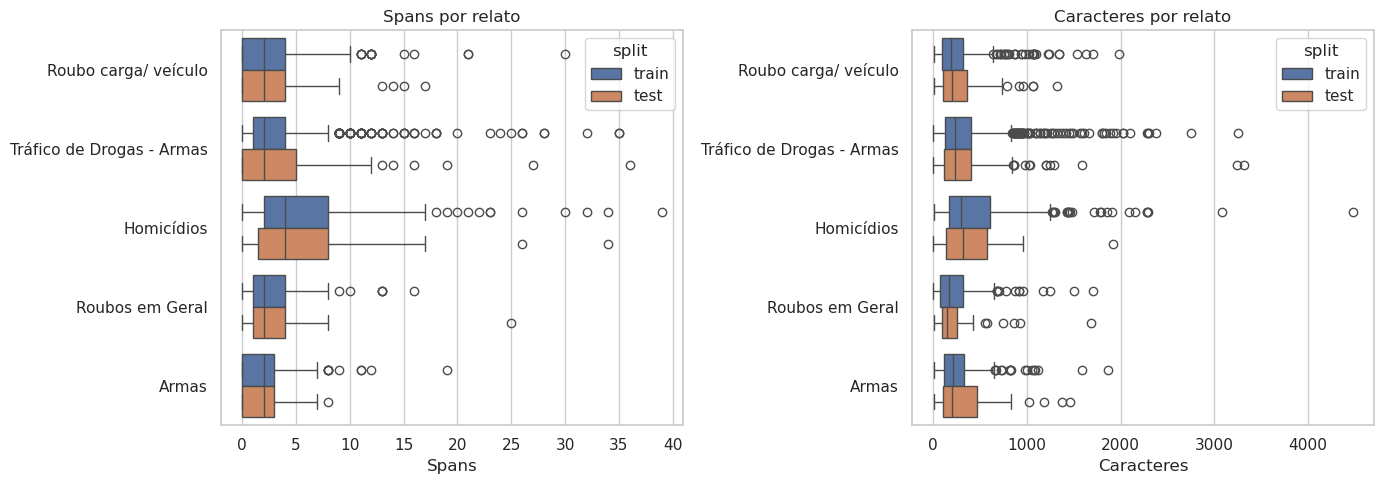

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if sns is not None:
    sns.boxplot(data=df_subject, x="span_count", y="assunto", hue="split", ax=axes[0])
    sns.boxplot(data=df_subject, x="text_chars", y="assunto", hue="split", ax=axes[1])
else:
    df_subject.boxplot(column="span_count", by=["assunto", "split"], ax=axes[0], vert=False)
    df_subject.boxplot(column="text_chars", by=["assunto", "split"], ax=axes[1], vert=False)
axes[0].set_title("Spans por relato")
axes[0].set_xlabel("Spans")
axes[0].set_ylabel("")
axes[1].set_title("Caracteres por relato")
axes[1].set_xlabel("Caracteres")
axes[1].set_ylabel("")
plt.tight_layout()

## Relatos sem assunto recuperado

Esses casos não entram na comparação principal de distribuição de `assunto`, mas devem ser reportados como limitação.

In [13]:
missing_summary = (
    df[~df["has_assunto"]]
    .groupby(["split", "match_status"])
    .agg(
        rows=("text", "size"),
        median_chars=("text_chars", "median"),
        avg_spans=("span_count", "mean"),
    )
    .reset_index()
)
missing_summary

,split,match_status,rows,median_chars,avg_spans
0,test,matched_ambiguous_assunto,39,227.0,3.230769
1,test,unmatched,243,288.0,5.131687
2,train,matched_ambiguous_assunto,188,205.0,2.329787
3,train,unmatched,1436,283.0,4.047354


In [14]:
sample_cols = ["split", "match_status", "text_chars", "span_count", "text"]
df[~df["has_assunto"]].sample(min(10, (~df["has_assunto"]).sum()), random_state=42)[sample_cols]

,split,match_status,text_chars,span_count,text
3171,train,unmatched,215,4,"Um Grupo de Bandidos da Comunidade do Machado , Armados estão na Comunidade da Caixa D'Gua em Belford Roxo numa Casa Localizada na Rua Peso número 13 fundos , Portão Grande Ver..."
263,train,unmatched,546,6,"Em Campo Grande RJ na estrada da cachamorra largo do 500 , na rua caminho da mandinga , numa casa Branca velha em frente a um sítio lago azul , desconfiamos que está a vendo um..."
4832,test,unmatched,397,4,"É um verdadeiro inferno , principalmente nos finais de semana , a circulação de motocicletas entre as ruas Guarabu e Afonso de Albuquerque ( ruas de acesso ao morro do Engenho ..."
4368,test,unmatched,283,5,HOJE MAS UM CRIME NO CAMPO DA CAROBA PARABÉNS GOVERNO MAS UMA VÍTIMA TO LIGADO A UM MÊS E NADA DOU NOME Fotos desses bandidos monstros vou terque mandar uma carta pro diretor d...
1086,train,unmatched,531,3,HOJE SERA REALIZADA UMA FESTA RUA HILARIO RIBEIRO NÚMERO 22 INTITULADA PAGODE DA FIRMA ONDE ELES FECHAM A RUA SEM AUTORIZACAO ONDE É CONSUMO DE DROGAS VENDA DE BEBIDAS A MENORE...
3521,train,unmatched,89,1,"Baile funk ocorrendo no bairro Almerinda , com perturbação da ordem e venda de ilícitos ."
169,train,unmatched,265,6,""" O CONDOMÍNIO VILA PORTUÁRIA PRES . DUTRA RUA AMERICA , 81- PROVIDENCIA - STO . CRISTO-RJ , VIVE ACOADO PELO TRAFICO ARMADO NO INTERIOR DOS VARIOS BLOCOS , INCLUSIVE COM "" "" A..."
1380,train,unmatched,128,2,""" Estão enterrados armas , drogas e corpos as fundos da favela da rainha da sucata em cabo frio o cheiro está insuportável . Obs"
1589,train,unmatched,408,5,Todos os dias agora ficamos a mercê de indivíduos armados que impedem-nos de circular nas ruas de nossas casas ! Revistam e esculacham os moradores Estamos trancados e com medo...
4090,train,unmatched,690,13,"Boa noite , tá rolando áudio aqui em belford Roxo que vinheram 45 homens fortemente armados da Nova Holanda da facção comando vermelho onde teve uma reunião no chapadão p tomar..."


## Exportação de tabelas

As tabelas abaixo são salvas em `artifacts/eda/enriched_train_test/` para uso no texto ou em anexos.

In [15]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

coverage.to_csv(OUT_DIR / "assunto_coverage.csv")
match_status_table.to_csv(OUT_DIR / "match_status_table.csv")
comparison.sort_values("train_n", ascending=False).to_csv(OUT_DIR / "subject_distribution_comparison.csv")
similarity_metrics.to_csv(OUT_DIR / "subject_distribution_similarity_metrics.csv", index=False)
dist_compare.sort_values("abs_diff", ascending=False).to_csv(OUT_DIR / "subject_distribution_share_differences.csv")
entity_by_subject.to_csv(OUT_DIR / "entity_profile_by_subject.csv", index=False)
missing_summary.to_csv(OUT_DIR / "missing_assunto_summary.csv", index=False)

print(f"Saved EDA tables to: {OUT_DIR.resolve()}")

Saved EDA tables to: /home/ebezerra/ailab/nerdd/artifacts/eda/enriched_train_test
